# 리포트 07 — 마이크로도플러 한눈에 보기

> **도는 로터가 만드는 무늬는 회전수·가림·자세가 정한다.**

이 편은 **부 7 의 표지**다. 그림 다섯 장을 한자리에 놓고 각각이 무엇을 말하는지 한 줄로 적는다. 자세한 것은 각 절이 가리키는 편에 있다.

| 그림 | 무엇을 말하나 | 자세히 |
|---|---|---|
| 1 | 회전수가 같으면 무늬가 시간에 안 변한다 | `reports/37_md-rpm.ipynb` |
| 2 | 두 엔진이 날개끝 아래에서 겹치고 위에서 갈린다 | `reports/36_md-two-engines.ipynb` |
| 3 | ⭐세 엔진을 같은 격자에 태우면 | `reports/36_md-two-engines.ipynb` |
| 4 | 블레이드는 강하고 동체가 덮는다 | `reports/39_md-blade-vs-body.ipynb` |
| 5 | 동체가 막으면 무엇이 달라지나 | `reports/38_md-occlusion.ipynb` |
| ⭐6 | **블레이드 플래시가 7.9 ms 마다 번쩍인다** | 아래 |
| ⭐7 | 2초 호버링 — 능선과 로터 회전수 | 아래 |

헤드라인 칸은 **DJI Matrice 4E** 를 배 쪽에서 본 것이다 — 방위 0° · 앙각 -15° · 호버 3800 rpm · 날개끝 주파수 1230 Hz · 블레이드 통과율 126.7 Hz.

⚠ 이 편의 숫자는 각도의존 Γ(θ) 수정 **이전** 계산에서 나왔다. 재계산 뒤 다시 짓는다.


## §0. 시나리오 — 그림을 보기 전에

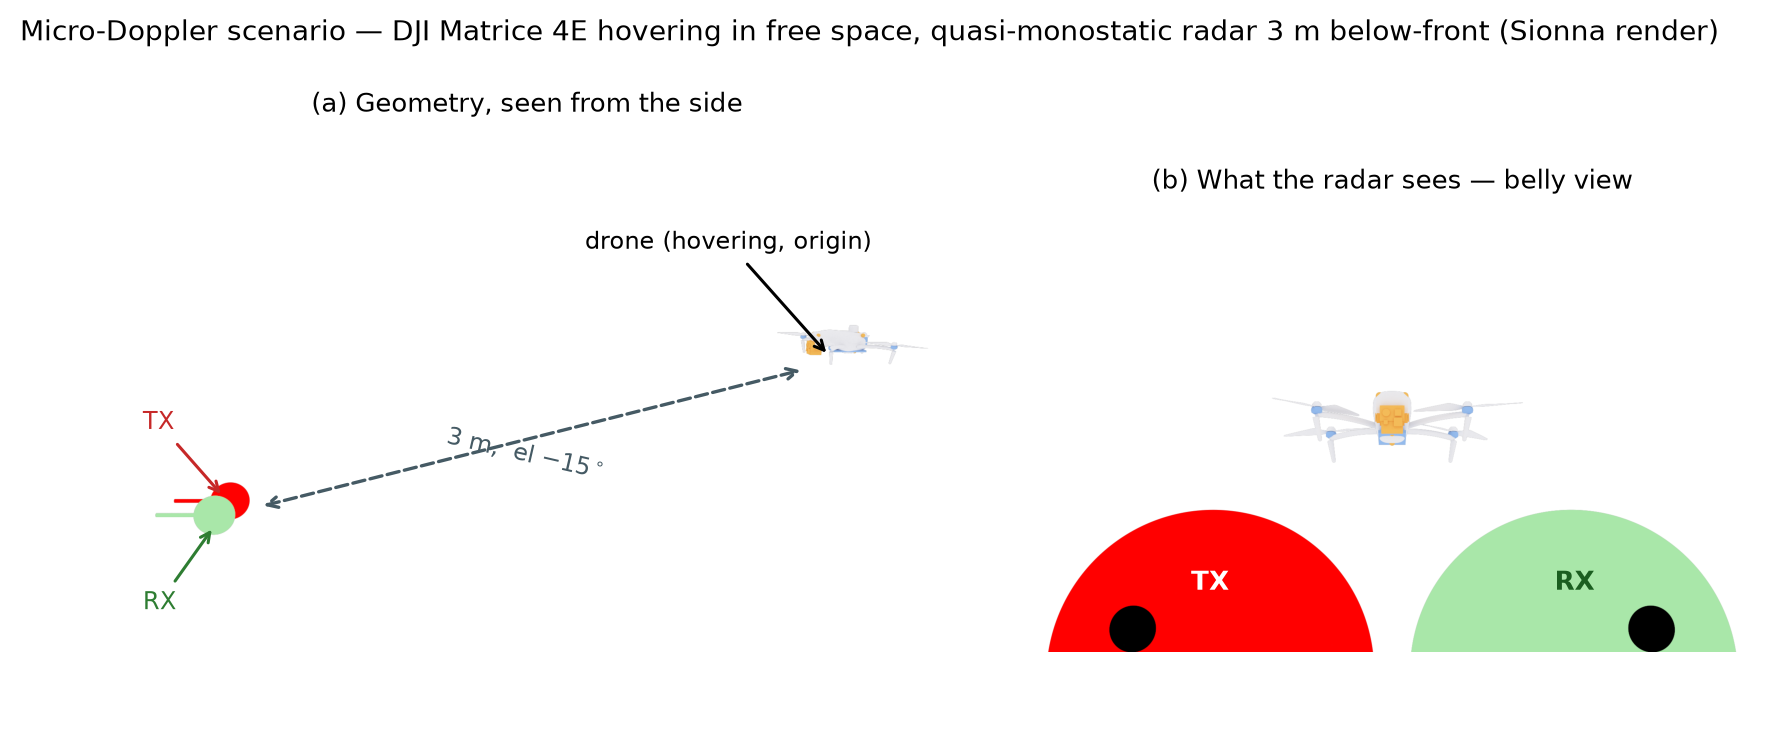

**공통**: DJI Matrice 4E 한 대가 **제자리 호버링**한다(이동 0, 벌크 도플러 0). 환경은 자유공간이다 — 지면도 벽도 클러터도 잡음도 두지 않았다. 레이더는 기체의 **배 쪽 아래**에서 본다(방위 0°, 앙각 −15°). 지상 레이더가 나는 드론을 보는 각도다.

⚠ **두 종류의 그림이 서로 다른 파면을 쓴다.** 어느 그림이 어느 쪽인지 아래에 적는다.

**A. 원거리장 평면파** — 그림 1 · 6 · 7 (우리 SBR+PO 단독)

| | |
|---|---|
| 배치 | TX/RX 없음 — **시선 방향 하나**만 준다 (거리 무한대 가정) |
| 시선 | û = (+0.966, 0, −0.259), 즉 기체 앞-아래 15° |
| 뜻 | «충분히 먼 모노스태틱 레이더가 이 방향에서 본다» |

**B. 근거리 준-모노스태틱** — 그림 3 (세 엔진 비교, Sionna 씬)

| | 좌표 [m] (드론 중심 = 원점) |
|---|---|
| TX | (+2.898, −0.100, −0.776) |
| RX | (+2.898, +0.100, −0.776) |
| 거리 | **3 m** · 기선 0.2 m · 바이스태틱각 3.8° |

⚠ **3 m 는 근거리장이다** — 이 기체의 원거리장 경계는 2D²/λ = **8.0 m** 다. 세 엔진 비교를 3 m 에서 한 이유는 Sionna 경로해가 근거리에서 경로를 더 안정적으로 찾기 때문인데, 그 대가로 **A 그림들과 파면 조건이 다르다**. 같은 자세인데 그림 3 과 그림 1 의 무늬 세부가 다른 이유 중 하나가 이것이다.

⚠ 시나리오에 **없는 것**도 그림을 읽는 데 필요하다 — 잡음 0 · 클러터 0 · 지면 반사 0. 그래서 이 그림들의 «깨끗함» 은 성과가 아니라 설정이다. 지면·클러터는 향후 과제로 두었다(야외 사이트 트윈).


## 그림 1 — 회전수가 같으면 무늬가 시간에 안 변한다

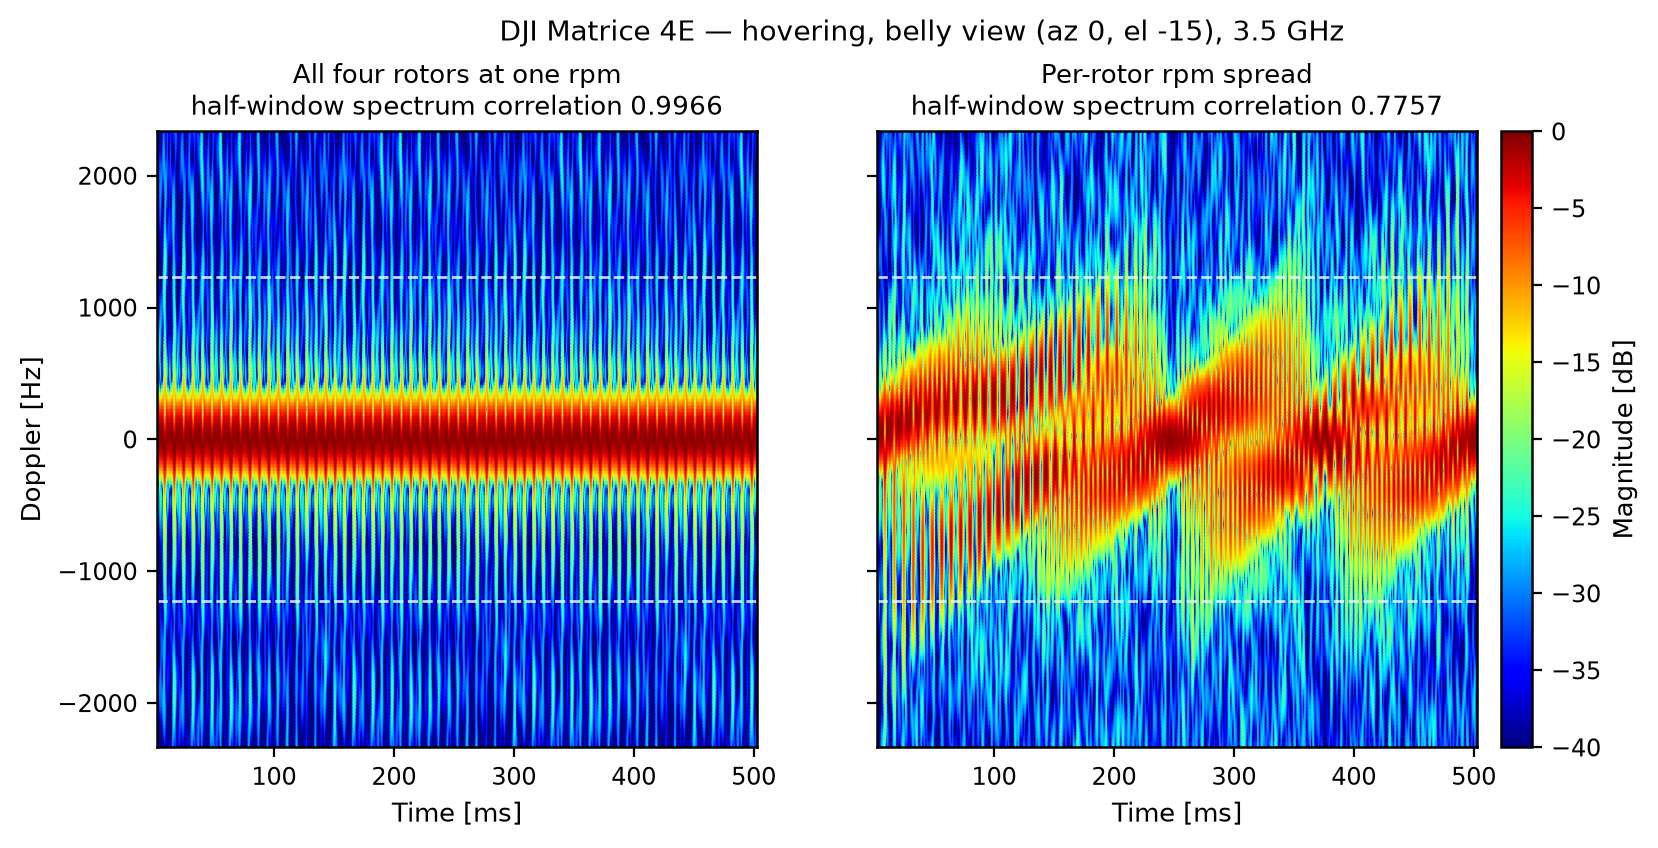

왼쪽은 네 로터를 같은 회전수로 돌린 것이다. 줄무늬가 시간축 내내 같은 자리에 선다 — 창을 반으로 갈라 두 스펙트럼의 상관을 재면 **0.9966** 다.

⭐ 우연이 아니라 **원리**다. 네 로터가 같은 속도로 위상까지 맞춰 돌면 신호가 완전한 주기함수가 되고, 주기함수의 스펙트로그램은 창 내내 자기 모습을 지킨다. 그건 물리가 아니라 **가정의 성질**이다.

오른쪽은 로터마다 회전수를 2% 흩뜨린 것이다. 상관이 **0.7757** 로 내려가고 줄이 숨쉬듯 흔들린다.

⚠ 흩어짐 폭은 **선언된 가정**이다 — 실측 비행 로그는 앞으로 확보한다.


## 그림 2 — 두 엔진이 날개끝 아래에서 겹치고 위에서 갈린다

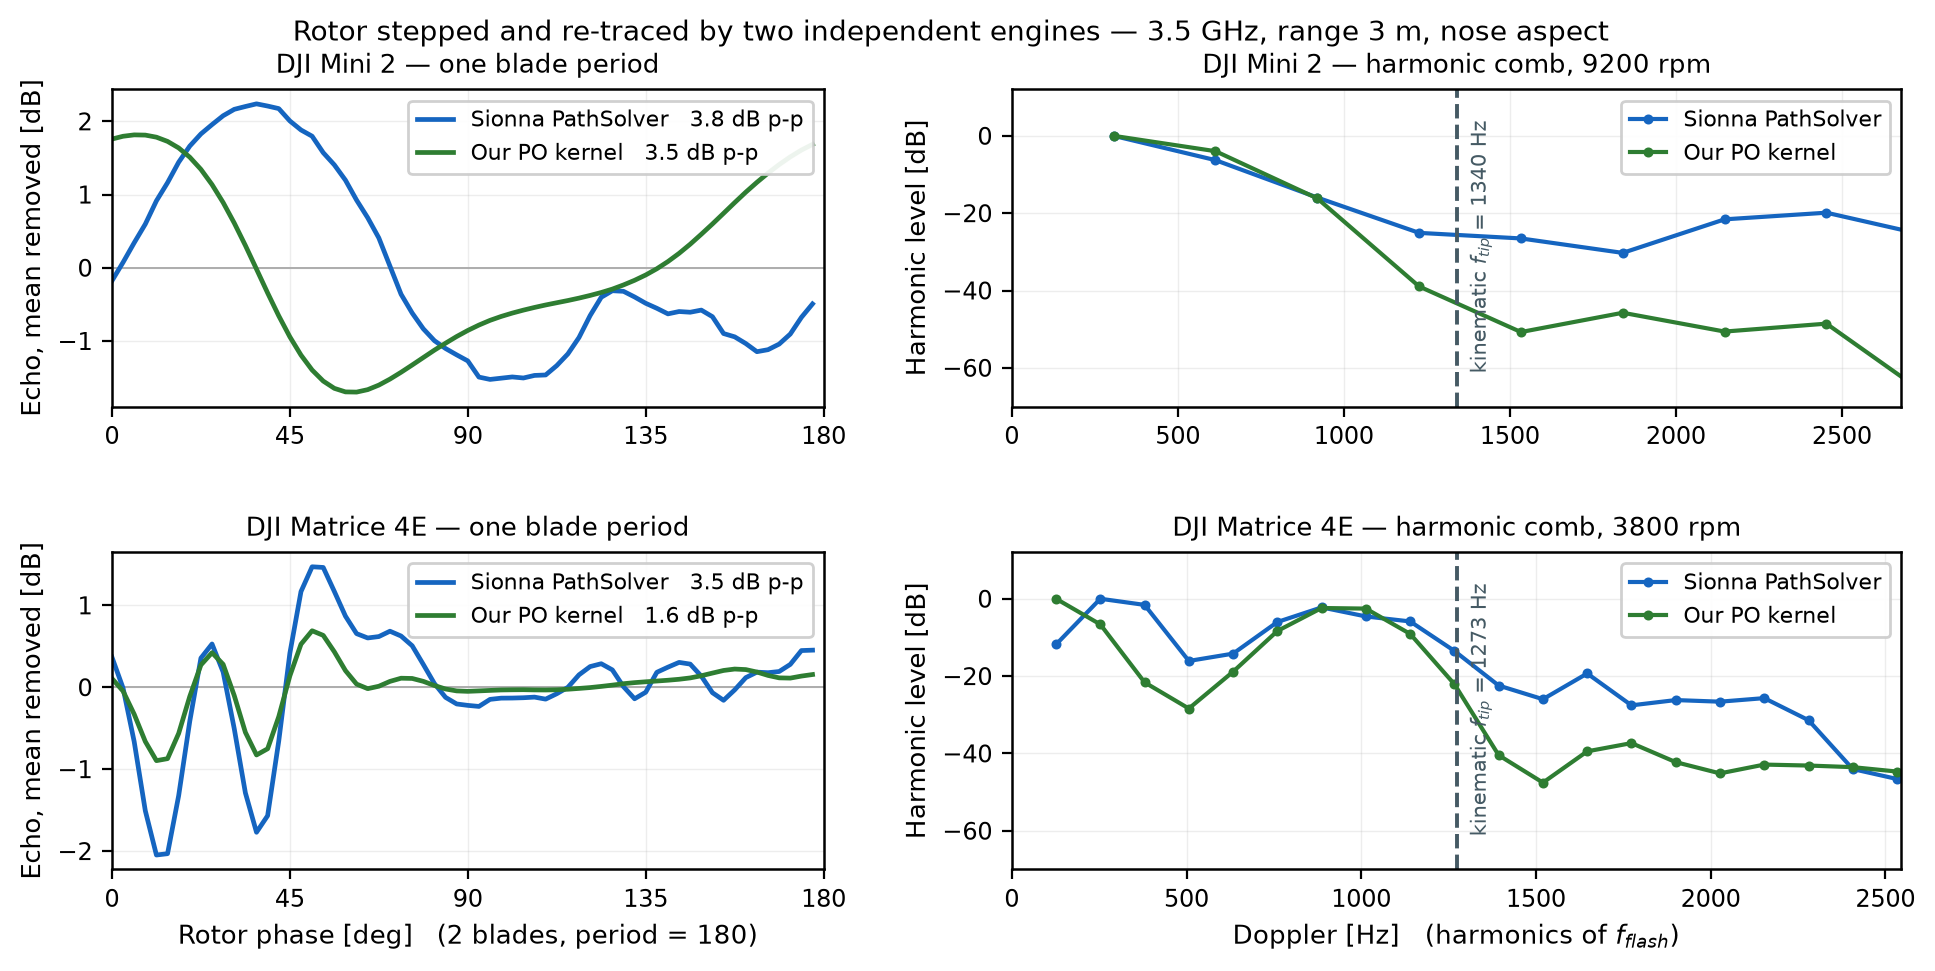

로터 위상을 스텝하고 매번 다시 추적하는 같은 절차를 **서로 다른 두 엔진**에 태웠다 — 하나는 Sionna 의 PathSolver 이고 하나는 우리 PO 커널이다.

운동학이 예측한 날개끝 주파수 **아래**에서 두 빗살이 겹친다. ⭐ 그 위에서 Sionna 의 꼬리가 20~30 dB 높게 남는다 — 그 꼬리는 블레이드가 만든 것이 아니므로, 가장자리를 자동으로 찾는 검출기는 물리적이지 않은 자리를 가장자리라고 보고한다.


## 그림 3 — ⭐세 엔진을 같은 격자에 태우면

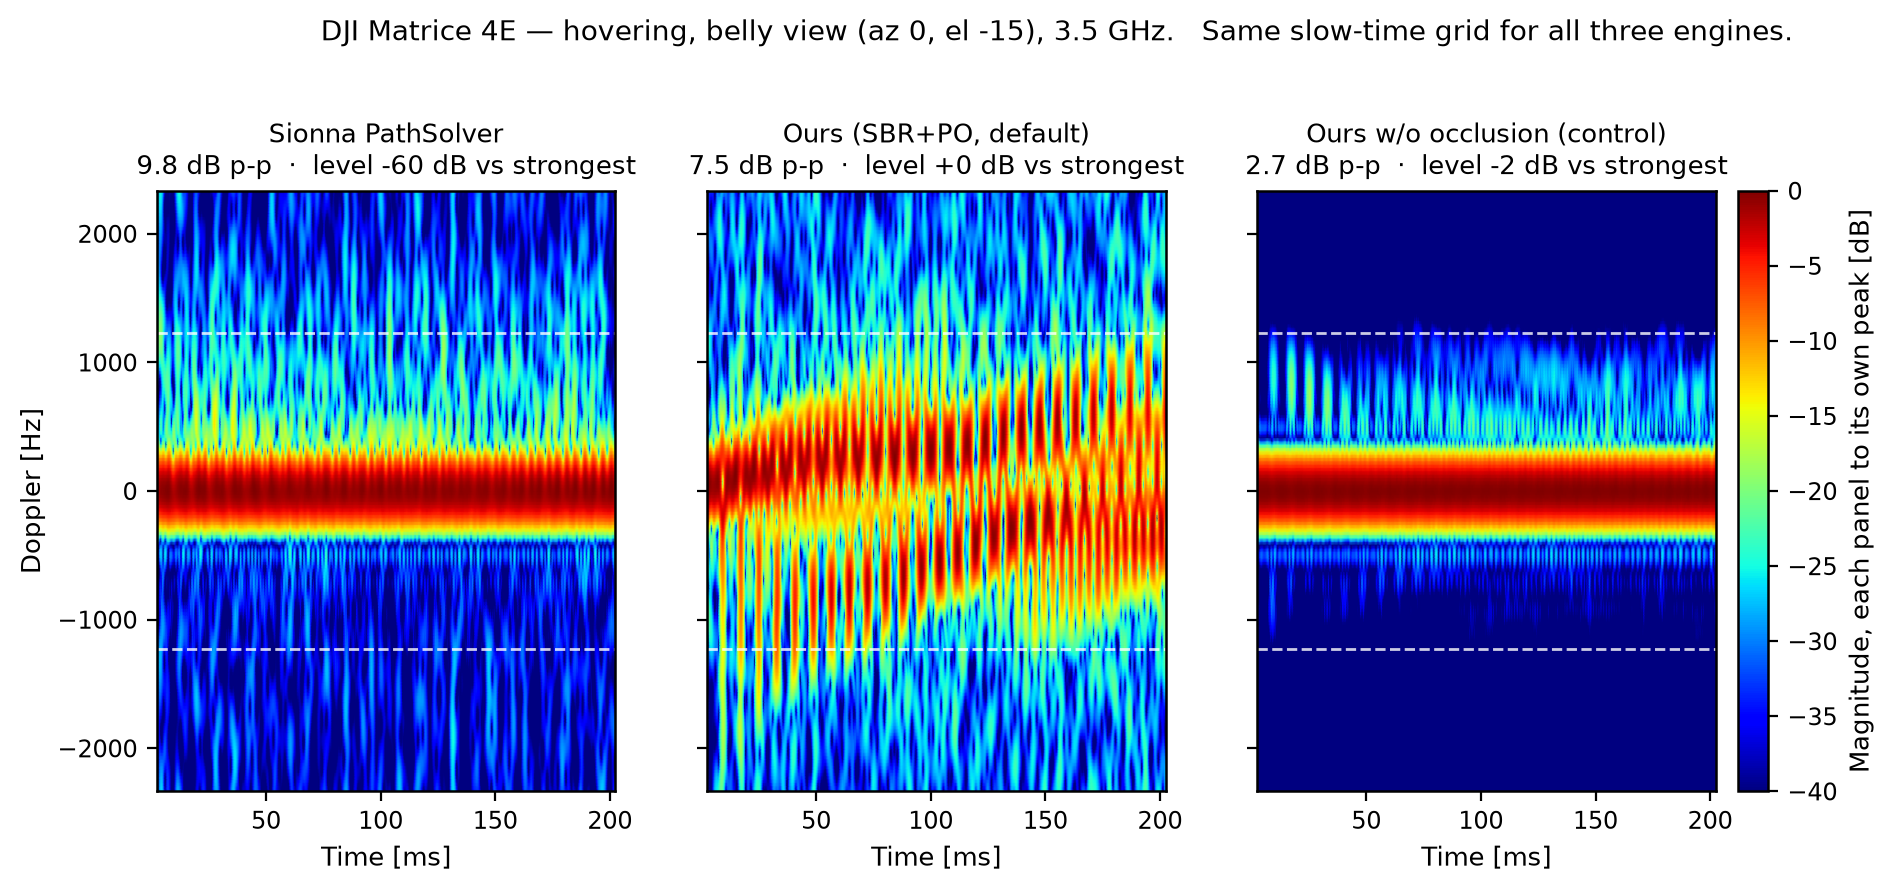

같은 기체·자세·주파수·PRF·로터별 회전수로 세 엔진을 돌렸다 — 1024 표본 @ PRF 5000 Hz = 26 블레이드 주기.

| 엔진 | 변조 p-p | 무늬 |
|---|---|---|
| Sionna PathSolver | 9.8 dB | 능선이 성기고 날개끝 근처에서 잦아든다 |
| 우리 SBR | 7.5 dB | ⚠능선이 대역을 채우고 날개끝 밖에도 남는다 |
| 우리 순수 PO | 2.7 dB | 능선이 몇 가닥에 그친다 |

⭐ 셋 다 **(a) 0 도플러 동체 선 · (b) 통과율 간격 능선 · (c) 날개끝 근처 감쇠**를 낸다 — 구조가 일치한다. 날개끝 안 스펙트럼 코사인은 Sionna↔SBR **0.657** · Sionna↔PO **0.696** · SBR↔PO **0.647** 다.

⚠ 다만 0.65~0.70 은 «닮았다» 까지다. 능선의 세기·밀도가 갈리고 이유가 각각 있다 — 순수 PO 는 가림을 빼고 계산하므로 변조가 씻기고, Sionna 는 경로가 열 개 남짓이라 성기고, ⚠**우리 SBR 은 날개끝 주파수 밖에도 능선을 낸다**(운동학이 금지한 자리). 그 하나가 남은 의심이고 `reports/42_md-ray-budget.ipynb` 가 그것을 잰다.


## 그림 4 — 블레이드는 강하고 동체가 덮는다

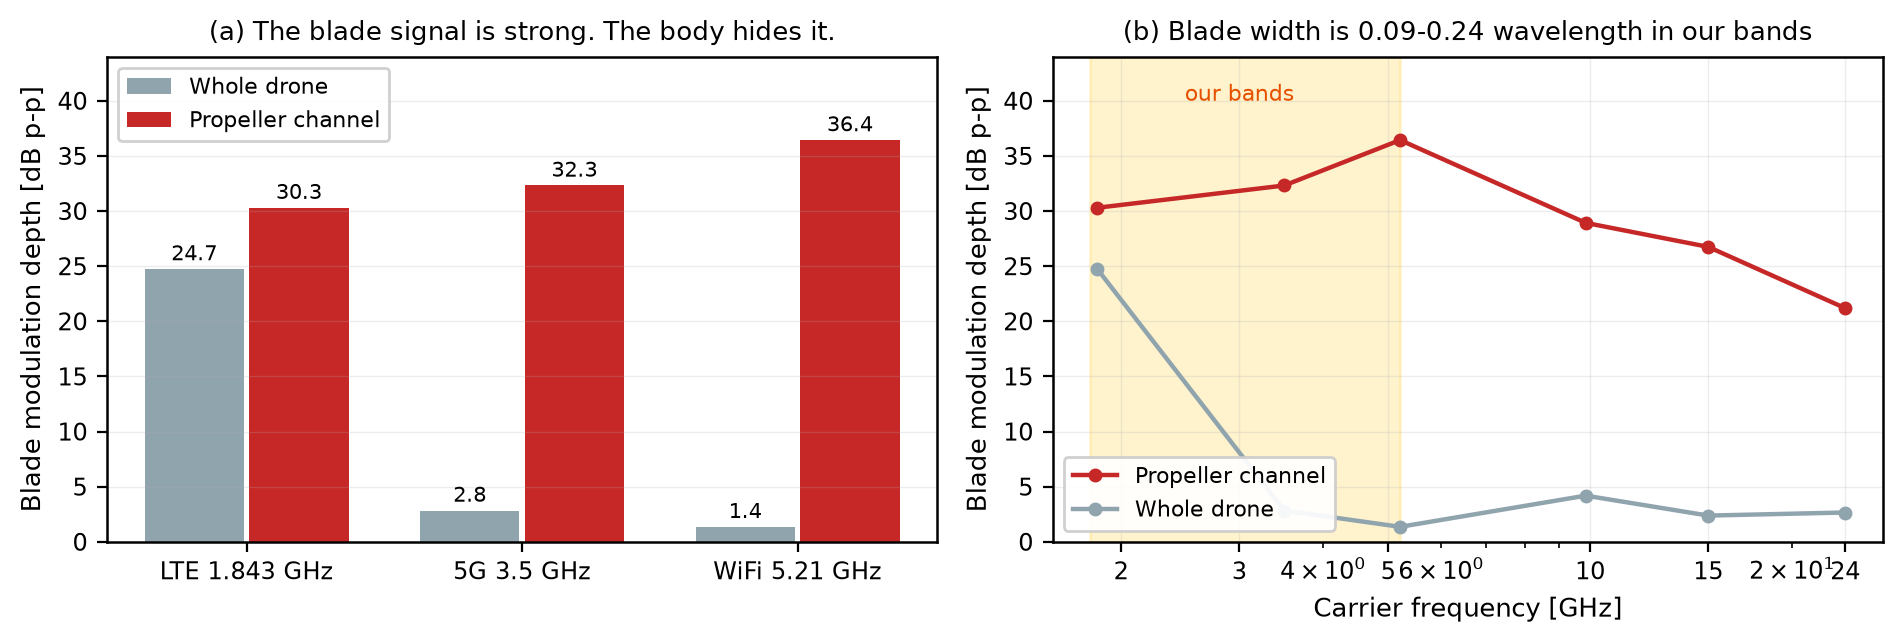

같은 자세·같은 주파수에서 전체 드론과 프로펠러 채널을 따로 쟀다. 3.5 GHz 에서 전체 드론의 변조는 **2.84 dB**, 프로펠러만은 **32.32 dB** 다.

⭐ 블레이드 신호가 약한 것이 아니라 **동체 정적 반사가 덮고 있다**. 이것이 전처리에서 정적 성분을 지우는 이유다.

⚠ 우리 대역에서 블레이드 폭은 파장의 0.09~0.24 배로 전기적으로 작은데, 그래도 변조 자체는 충분히 크다. 어려운 것은 «블레이드가 약하다» 가 아니라 «동체와 블레이드를 가르는 일» 이다.


## 그림 5 — 동체가 막으면 무엇이 달라지나

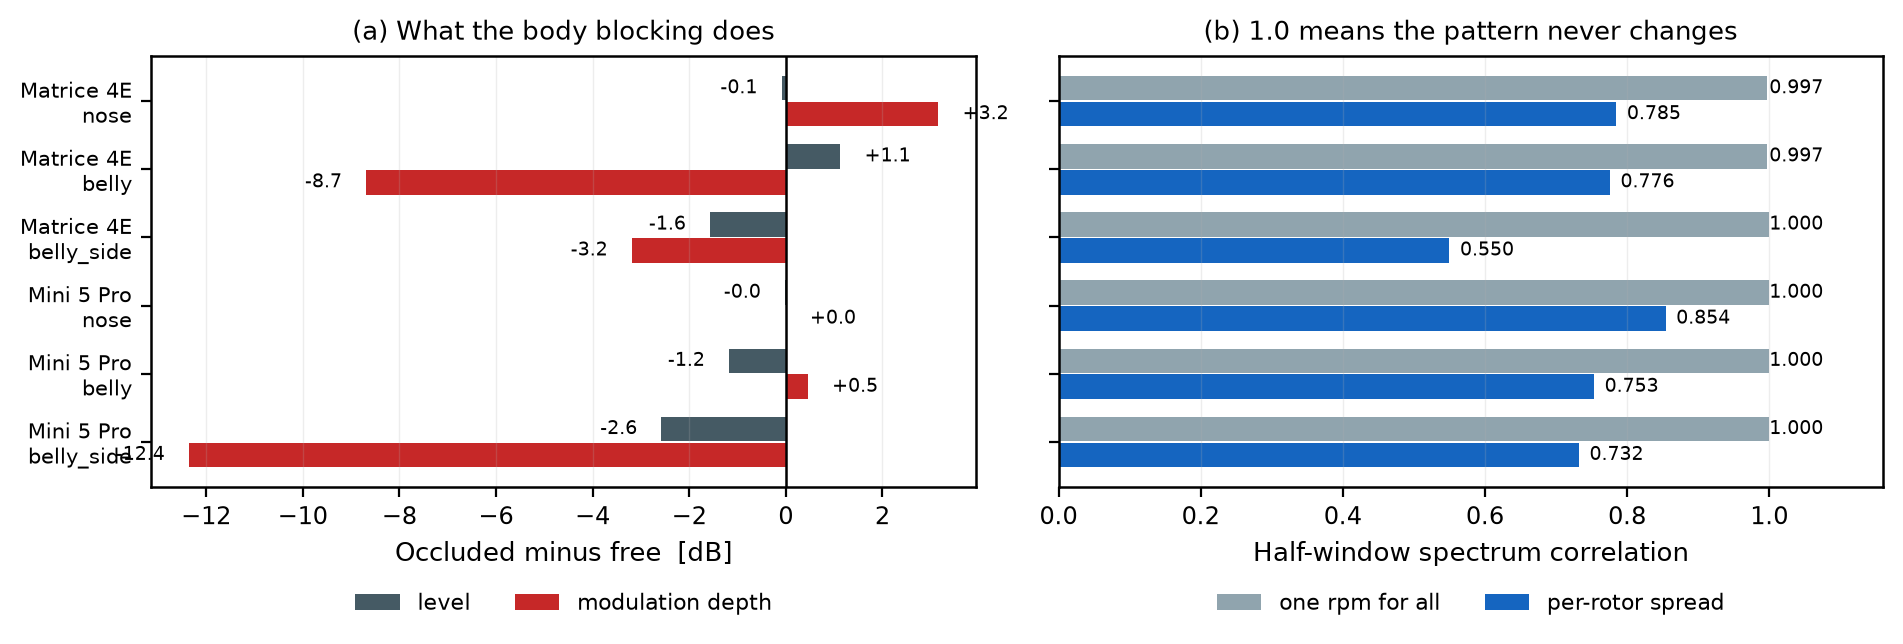

가림만 남기고 다른 것을 전부 묶었다. 한쪽은 동체를 완전흡수로 두어 **광선은 막되 산란은 안 하게** 하고, 다른 쪽은 동체 면만 빼되 정점 배열은 남겨 두었다 — 정점을 남기면 경계상자가 같아서 두 팔의 광선 수와 간격이 같아진다.

헤드라인 칸에서 가림이 변조 깊이를 **-8.69 dB**, 레벨을 **+1.13 dB** 바꾼다.

⚠ 부호를 물리로 단정하지 않는다 — 합이 코히런트라 항이 줄어도 남은 항끼리 상쇄가 덜 되면 레벨이 올라갈 수 있고, 실제로 그런 칸이 있다.

⚠ 프로펠러가 동체 **위**에 있어 위에서 내려다보면 날개가 통째로 드러난다. 지상 레이더는 기체를 **아래에서** 보므로 이 편의 자세는 배 쪽이다.


## 그림 6 — ⭐블레이드 플래시가 보인다

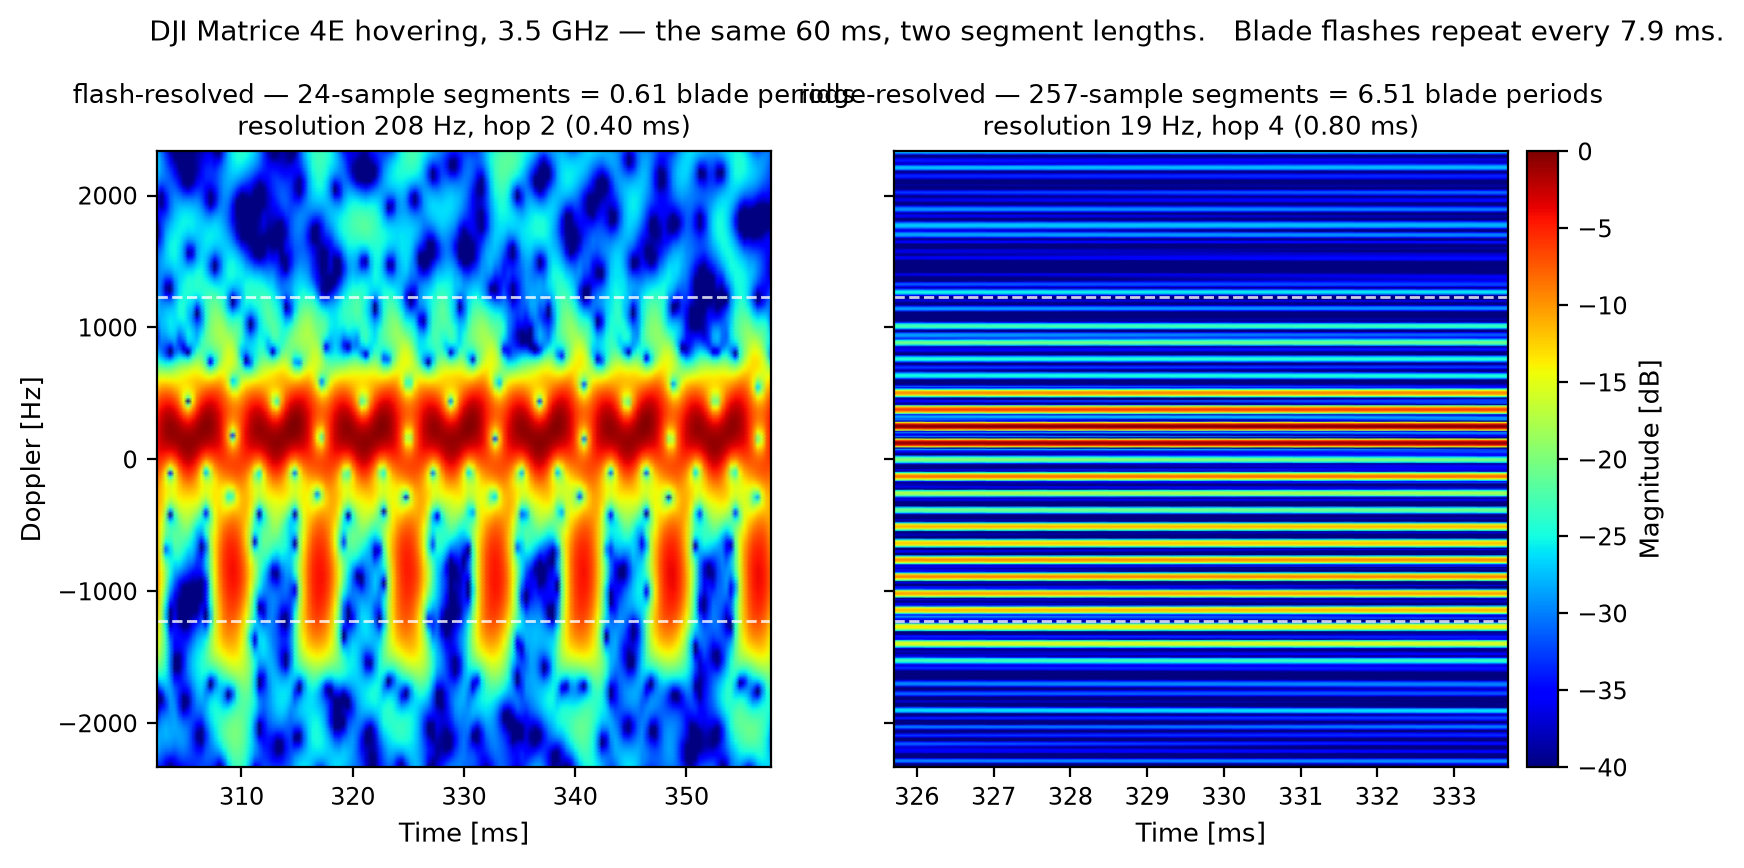

같은 데이터를 **조각 길이만 바꿔** 두 번 그렸다. 왼쪽은 조각이 블레이드 한 주기보다 짧아(0.61 주기) **플래시 아치가 7.9 ms 마다 또렷하다**. 오른쪽은 조각이 6.5 주기라 그 아치가 시간평균으로 지워지고 능선만 남는다.

⭐ 이것이 시간·주파수 분해능의 **맞바꿈**이다. 둘 다 동시에는 원리적으로 못 본다 — 짧은 조각은 플래시를 보여주고 주파수를 뭉개고, 긴 조각은 그 반대다.

⚠ 그동안 우리 그림에 플래시가 안 보였던 이유가 조각을 6.5 주기로 잡은 것이었다. 물리가 아니라 표시 설정이었다.


## 그림 7 — 2 초 호버링, 능선과 로터 회전수

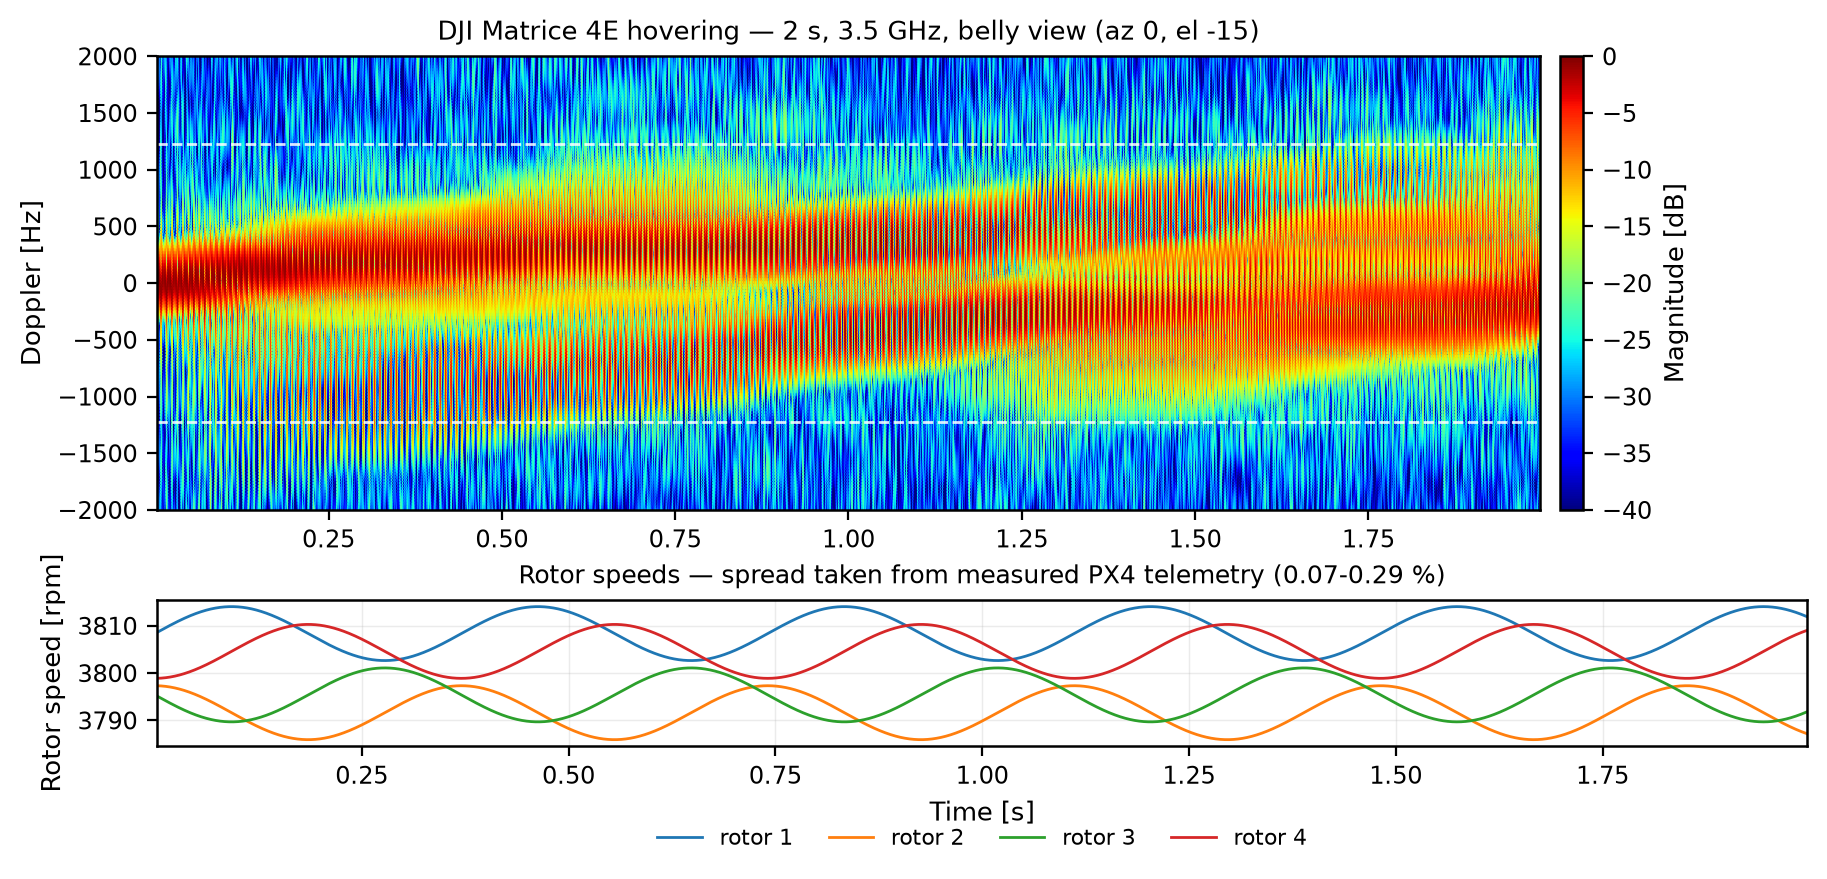

2 초 · 10,000 표본 · 253 블레이드 주기. 아래 패널이 네 로터의 회전수다 — 능선이 어떻게 움직이는지의 원인이 거기 있다.

⭐ 로터별 산포를 **0.22%** 로 뒀다. 이것은 추측이 아니라 선배(홍지혁)의 PX4 텔레메트리를 직접 재서 나온 값이다(모터 간 0.07~0.29 %).

⚠ 한때 나는 그 실측을 «너무 작아 비현실적» 이라 여기고 ±2 % 를 넣었다. 그러자 네 로터의 빗살이 고조파마다 어긋나 **맵이 뭉개졌다**. 문헌 그림의 능선이 가늘고 선명한 이유가 로터들이 거의 같은 속도이기 때문이다.

⚠ 제어루프 흔들림(±0.15% @ 2.7 Hz)은 아직 **선언된 가정**이다 — 실측 비행 로그가 그 자리를 채운다.


## 부록 — 그림을 만든 설정 전부

그림에는 설정 수치를 안 적는다. 여기가 그 수치들의 자리다.

**계산 (슬로타임 복소열)**

| 항목 | 값 | 근거 |
|---|---|---|
| 기체 | DJI Matrice 4E | 1차 실측 표적 · 프롭-벨 겹침 0.01 % |
| 반송파 | 3.5 GHz | 5G n78 |
| 자세 | 방위 0° · 앙각 -15° | 지상 레이더는 아래에서 본다 |
| 거리 | 3 m (세 엔진 비교) | Sionna 씬 배치 |
| 호버 회전수 | 3800 rpm | Phantom 3 실측 C_T 로 푼 값 |
| 로터별 산포 | ±0.22% | ⭐PX4 텔레메트리 실측(0.07~0.29 %) |
| 제어루프 흔들림 | ±0.15% @ 2.7 Hz | ⚠선언된 가정 — 비행 로그가 채운다 |
| PRF | 5000 Hz = 4×f_tip | 나이퀴스트(2×f_tip)의 두 배 여유 |
| 관측 창 | 2 s = 10,000 표본 | 능선의 시간 변화를 보려고 |
| 광선 간격 | λ/16 | SBR 격자 (rcs_sbr 기본) |
| 재질 Γ | 각도의존 Γ(θ) 켬 | 2026-08-07 신설 · 수직입사에서 옛 값과 동일 |

**표시 (스펙트로그램) — `src/md_mapstyle.py` 가 한 자리에 강제한다**

| 항목 | 플래시 규약(기본) | 능선 규약(대조) | 왜 |
|---|---|---|---|
| 조각 길이 | **블레이드 0.6 주기** | 6.5 주기 | 플래시는 한 주기 안의 사건 — 길면 시간평균으로 지워진다 |
| 겹침(hop) | 2 표본 | 4 표본 | 시간 슬롯을 촘촘히 — ⚠정보는 안 는다 |
| 제로패딩 | 8배 | 2배 | 주파수축 보간 |
| 창 함수 | Hann | Hann | 누설 억제 |
| 음영 | gouraud | gouraud | 격자 경계를 지움 |
| 색 · 색역 | jet · 0~−40 dB | 같음 | 문헌 규약 |
| 0 도플러 | 살림 | 살림 | 동체 선이 읽기의 기준 |

⚠ **시간·주파수는 맞바꿈이다.** 짧은 조각은 플래시를 보여주고 주파수를 뭉개며(208 Hz), 긴 조각은 능선을 세우고 플래시를 지운다(10 Hz). 둘 다 동시에는 원리적으로 못 본다 — 그래서 그림 6 이 두 규약을 나란히 놓는다.

**용어 정정** — 그림의 «Ours (SBR+PO, default)» 와 «Ours w/o occlusion (control)» 은 별개 물리가 아니다. 산란식은 둘 다 PO 이고, 차이는 **어느 면을 셈에 넣느냐**다: 기본은 광선(SBR)이 보이는 면을 고르고, 대조는 법선만 보고 모든 면을 넣는다(가림 없음). 참고로 선배(홍지혁) 구현도 같은 철학이다 — 법선 검사 + Embree 레이캐스팅 가림 + PO 합. 차이는 가시성 판정(면 중심 1점 대 광선 격자)과 ⭐분해 저장(가림×재질 조합을 사후 복원) 이다.


## 이 편이 서 있는 자리

자세×로터위상 **1,152칸** 전수에서 프로펠러에 떨어진 정반사 경로는 **0칸** 이다. 위상은 광선 엔진이, 세기는 PO 커널이 맡는 이유가 여기 있다.

| 다음에 할 것 | 그러면 결정되는 것 |
|---|---|
| ⭐SBR 의 날개끝 밖 능선을 규명한다 | 광선 격자의 이산화 산물인지 물리인지 갈린다 |
| 각도의존 Γ(θ) 로 재계산한다 | 이 편의 모든 숫자가 갱신된다 |
| 비행 로그의 모터별 회전수를 넣는다 | 선언된 가정이 측정값으로 바뀐다 |
| 가림을 자세 전면으로 넓힌다 | 분류기가 배울 대비 지도가 선다 |

**세부 편** — `reports/34_md-paths-doppler` · `35_md-slowtime` · `36_md-two-engines` · `37_md-rpm` · `38_md-occlusion` · `39_md-blade-vs-body` · `40_md-attitude` · `41_md-calibration` · `42_md-ray-budget` · `43_md-prf`
